<a href="https://colab.research.google.com/github/Storm00212/SIGNALS-ASSIGNMENT-1/blob/main/QUESTION_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy # used scipy cuz numpy haina duty cycle,tho tutaeka na numpy kwa fourier

# PART A

# RECTANGULAR PULSE TRAIN FUNCTION

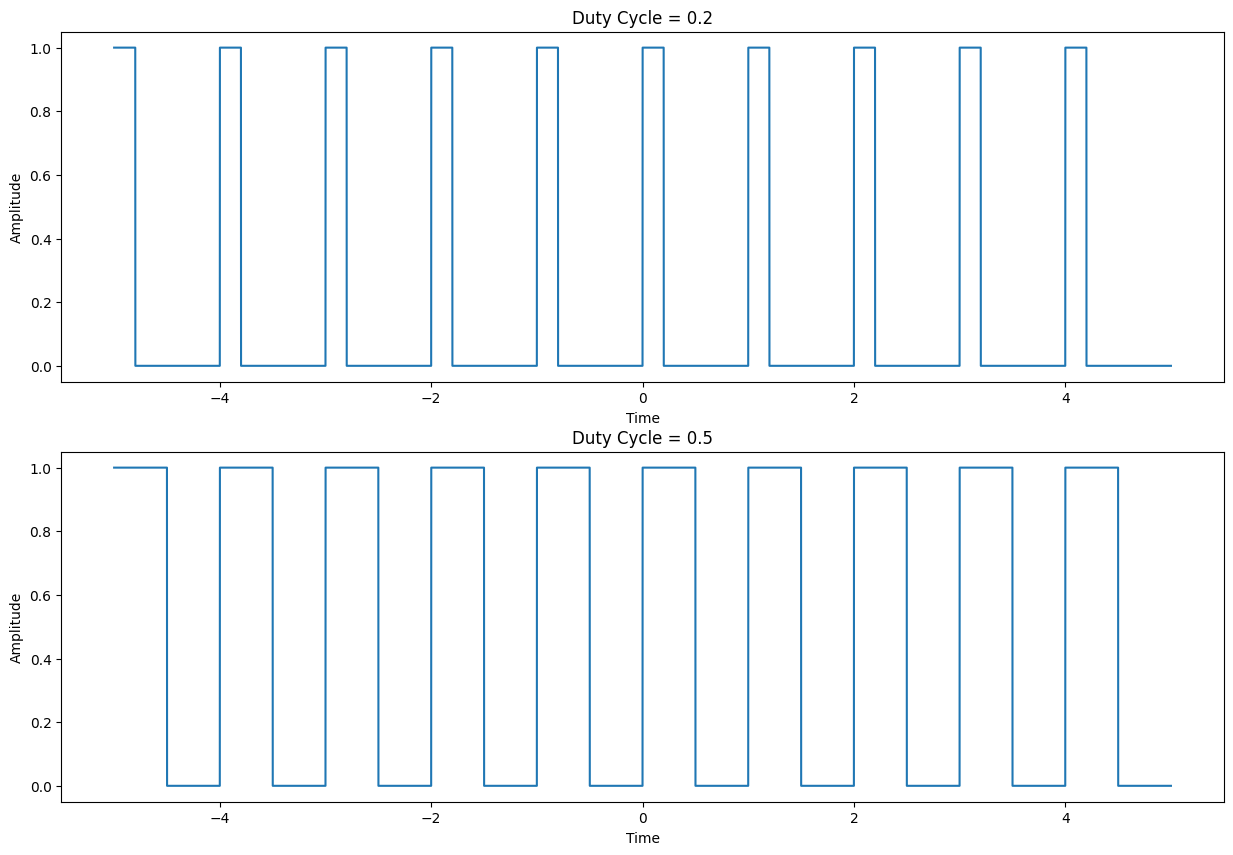

In [ ]:
# duty cycle = 0.5
from scipy import signal
t = np.linspace(-5, 5, 1000000, endpoint=False)# tumia samples mob za t ndo ifike value ya gibbs overshoot ukiplot(trust me bro).
duty_cycles = [0.2, 0.5] # what percentage of time does the signal stay on
frequency = 1 #no of cycles/second

# f = (np.sign(np.sin((2*np.pi*t*duty_cycle)/4))+1)/2 you can also do it manually but usijistress saii.
# dc = np.full_like(t, duty_cycle)
# ingebidi uadd izo for N values but saii nikudemonstrate nademonstrate.

fig, axes = plt.subplots(2, 1, figsize = (15, 10))
for i, duty_cycle in enumerate(duty_cycles):
    f = (scipy.signal.square(2 * np.pi * t, duty=duty_cycles[i])+1)/2 #can divide 2pit by the period u want.
    axes[i].plot(t, f)
    axes[i].set_title(f'Duty Cycle = {duty_cycle}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Amplitude')


# COMPUTING THE FOURIER SERIES COEFFICIENTS

Text(0.5, 1.0, 'Rectangular Pulse Train')

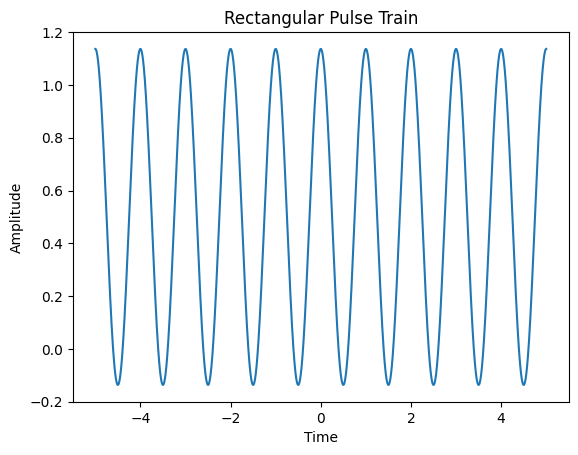

In [ ]:
# N = 1 TESTING TO SEE IF IT WORKS FIRST LOL.
f= 1/2 + (2/np.pi)*(np.cos(2*np.pi*t))
plt.plot(t, f)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Rectangular Pulse Train')

# 0.5 DUTY CYCLE

/tmp/ipykernel_40830/410337321.py:40: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout() # better plot layout
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


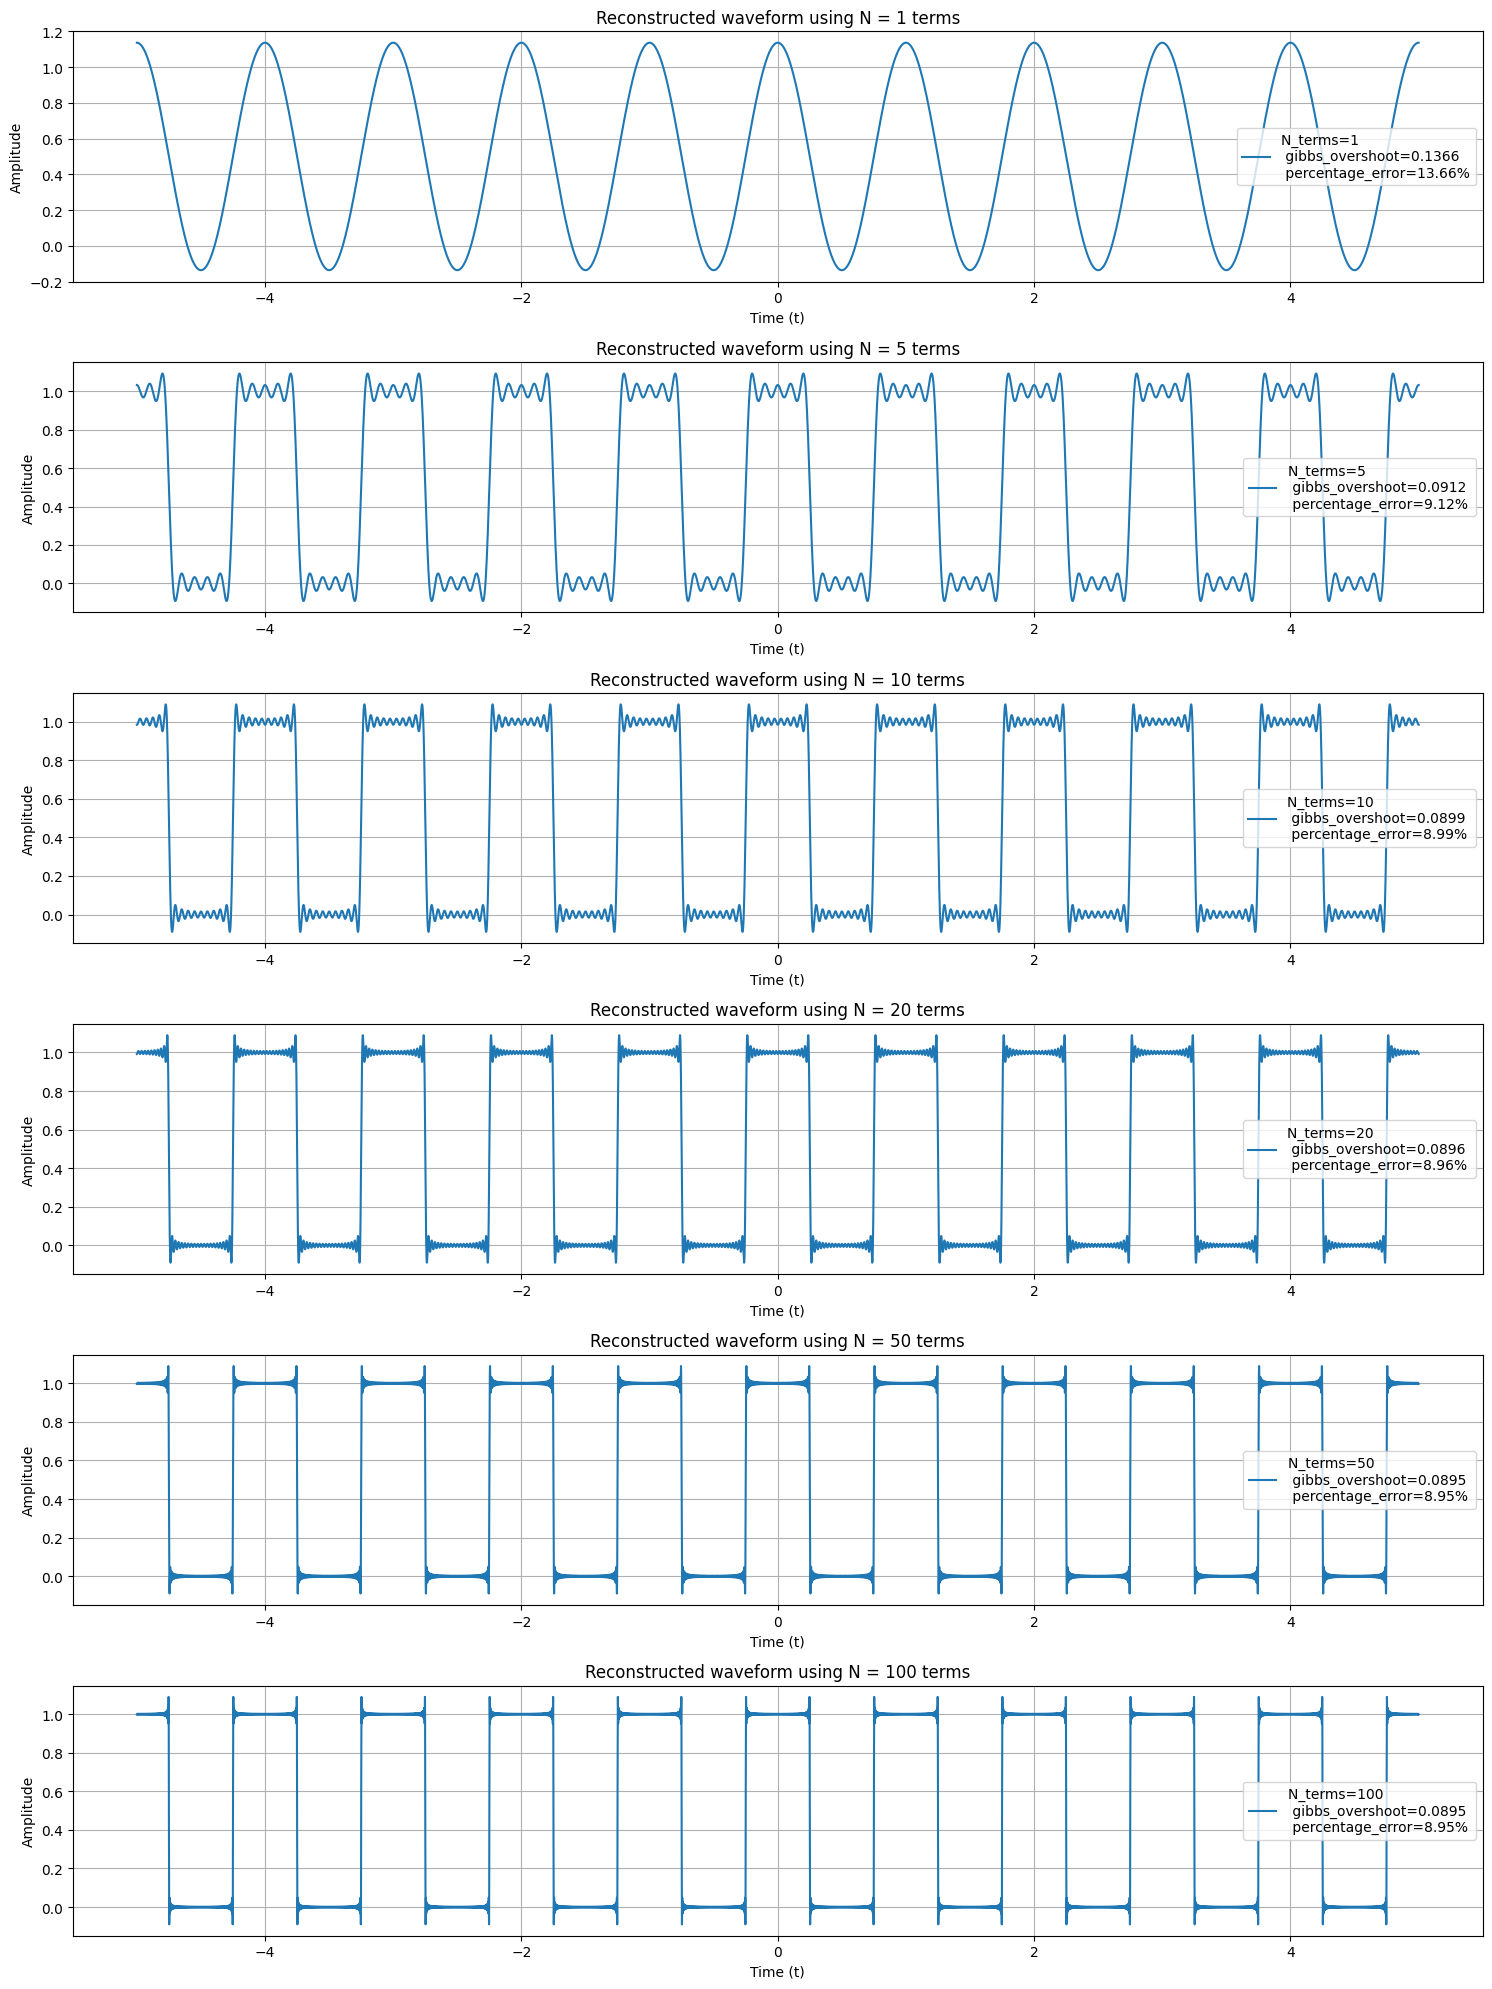

In [ ]:
k_values=[1, 5, 10, 20, 50, 100]
# to get k_term/n.
ideal_amplitude = 1.0 # tutatumia kufanya gibbs overshoot in a few.
def get_fourier_term(k_index, t_array):
  """Calculates k-th term of Fourier series n shii."""
  n_harmonic = (2 * k_index) + 1
  coefficient = ((-1)**k_index) / n_harmonic
  return coefficient * np.cos(n_harmonic * 2 * np.pi * t_array)


fig, axes = plt.subplots(len(k_values), 1, figsize=(15, 20))
for i, N_terms_to_sum in enumerate(k_values):

       # DC component (1/2)
       reconstructed_wave = np.full_like(t, 0.5)# tutatumia hii kucheza na DC values using maduty cycle.

       # Sum the Fourier series terms up to N_terms_to_sum
       # I tried integrating but it gives issues. unaeza test tho.
       for k_index in range(N_terms_to_sum):
           reconstructed_wave += (2 / np.pi) * get_fourier_term(k_index, t)# inasort kuadd izo N terms.

       max_amplitude_current = np.max(reconstructed_wave)

       # overshoot (absolute value)
       # Overshoot ni  max_amplitude - ideal_amplitude. Ka max_amplitude < ideal_amplitude, overshoot is 0
       gibbs_overshoot = max(0, max_amplitude_current - ideal_amplitude)

       #  percentage error(ni gibbs ka percentage tu)
       percentage_error = (gibbs_overshoot / ideal_amplitude) * 100

       axes[i].plot(t, reconstructed_wave, label=f'N_terms={N_terms_to_sum} \n gibbs_overshoot={gibbs_overshoot:.4f} \n percentage_error={percentage_error:.2f}%')
       axes[i].set_title(f'Reconstructed waveform using N = {N_terms_to_sum} terms duty cycle = 0.5')
       axes[i].set_xlabel('Time (t)')
       axes[i].set_ylabel('Amplitude')
       axes[i].legend()
       axes[i].grid(True)



plt.tight_layout() # better plot layout
plt.show()

# 0.2 DUTY CYCLE

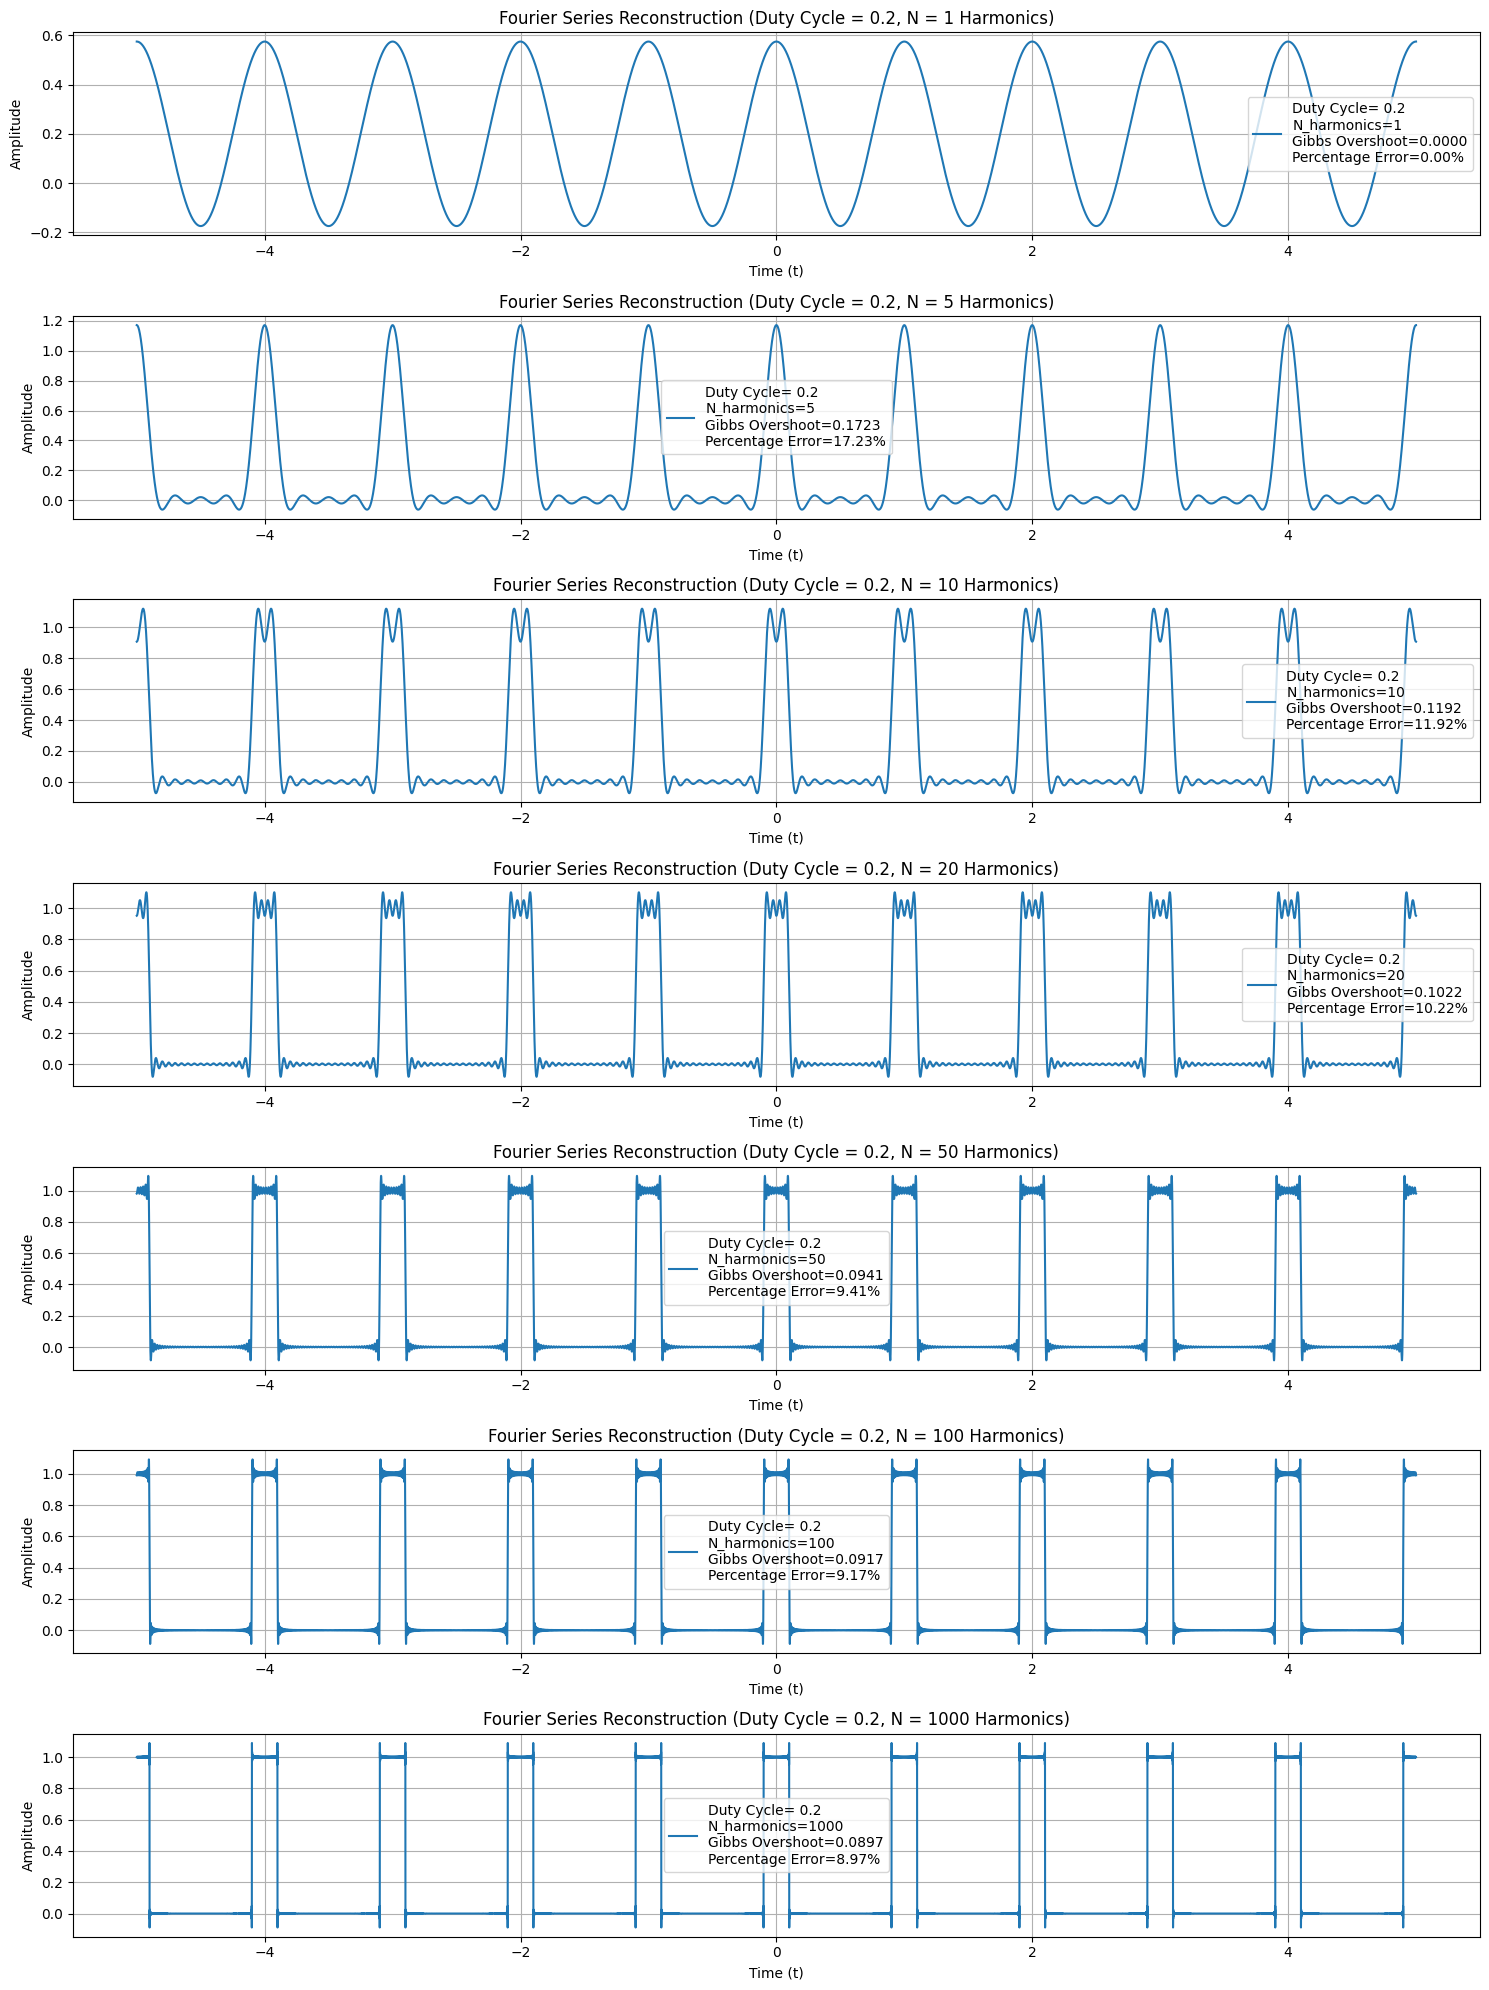

In [ ]:
# had to make new function for this
def reconstruct_fourier_series_with_duty_cycle(t_array, duty_cycle_val, num_harmonics):# only added duty cycle so...
  """Reconstructs Fourier series for a given duty cycle.
    so basically inachukua time ka array(cuz time ni continuous), duty cycle na harmonics unadai then inaunda io fourier.
  """
  # DC component
  reconstructed_wave = np.full_like(t_array, duty_cycle_val)# here it is!! our beautiful duty cycle. clap for me.

  # Sum harmonics
  for n in range(1, num_harmonics + 1):
    # Coefficient a_n for a unipolar square wave (0 to 1)
    a_n = (2 * np.sin(n * np.pi * duty_cycle_val)) / (n * np.pi)# put it in the function too since square wavw ni 1 for 0.2 of the period.
    reconstructed_wave += a_n * np.cos(n * 2 * np.pi * t_array)

  return reconstructed_wave



# Re-used  time array
t = np.linspace(-5, 5, 1000000, endpoint=False)


N_terms = [1, 5, 10, 20, 50, 100, 1000] # harmonics n shii.
ideal_amplitude = 1.0 # self explanatory

fig, axes = plt.subplots(len(N_terms), 1, figsize=(15, 20))

for i, N_term in enumerate(N_terms):
  reconstructed_wave = reconstruct_fourier_series_with_duty_cycle(t, 0.2, N_term)

  # Calculate Gibbs overshoot and percentage error
  max_amplitude_current = np.max(reconstructed_wave)
  gibbs_overshoot = max(0, max_amplitude_current - ideal_amplitude)
  percentage_error = (gibbs_overshoot / ideal_amplitude) * 100

  axes[i].plot(t, reconstructed_wave,
               label=(f'Duty Cycle= 0.2\n'  # Fixed: Added parentheses for multiline f-string
                      f'N_harmonics={N_term}\n'
                      f'Gibbs Overshoot={gibbs_overshoot:.4f}\n'
                      f'Percentage Error={percentage_error:.2f}%'))
  axes[i].set_title(f'Fourier Series Reconstruction (Duty Cycle = 0.2, N = {N_term} Harmonics)')
  axes[i].set_xlabel('Time (t)')
  axes[i].set_ylabel('Amplitude')
  axes[i].legend()
  axes[i].grid(True)

plt.tight_layout()
plt.show()

### Determining Number of Harmonics for a Given Percentage of Power



In [ ]:
# power+harmonics = dc power + harmonics power (parseval theorem)
# dc power = (a0)^2
# harmonics = (an^2)*0.5
# sin(pi/2) is -1 so you square that you just get 1 so use the other part 2/n*pi or don't idc.
total_signal_power = 0.5 # For a square wave (0 to 1) with 0.5 duty cycle(power ni duty cycle basically cuz ni 1 time iko on na t ni 1 so 1/T kwa power equation si ni 1 tu)
a = 0.9 * total_signal_power
b = 0.95 * total_signal_power
c = 0.99 * total_signal_power
targets=[a, b, c]# looping these bitches.

print(f"Total signal power: {total_signal_power:.2f}")

# Power from DC component
power_dc = (0.5)**2 # a_0 = 0.5
print(f"Power from DC component (a0^2): {power_dc:.4f}")
# used for loops cuz I aint writing allat fr.
for i, target in enumerate(targets):
  cumulative_power = power_dc
  k_index = 0
  N_harmonics_needed = 0
  harmonic_powers = [] # Reset for each target

  print(f"\nCalculating for target power: {target/total_signal_power:.0%}")
  print(f"Cumulative power after DC: {cumulative_power:.4f}")

  while cumulative_power < target:
    n_harmonic = (2 * k_index) + 1
    # The coefficient a_n is (2/pi) * ((-1)**k_index / n_harmonic) ukisquare sin(90)i.e (n*pi/2) ni 1 cuz (-1)^2 itakpea 1 tu so tumia the other coeff
    a_n = (2 / np.pi) * (((-1)**k_index) / n_harmonic)

    # Power of the n-th harmonic is 0.5 * a_n^2
    power_n = 0.5 * (a_n)**2
    harmonic_powers.append(power_n)

    cumulative_power += power_n
    N_harmonics_needed = k_index + 1 # k_index ni 0 ukianza, so add 1 for actual count

    print(f"Harmonic (n={n_harmonic}, k={k_index}): Power = {power_n:.6f}, Cumulative Power = {cumulative_power:.4f}")

    if cumulative_power < target:
        k_index += 1
    else:
        break
  print(f"\nTo capture {target/total_signal_power:.0%} of the total power, {N_harmonics_needed} odd harmonics (plus the DC component) are required.")

Total signal power: 0.50
Power from DC component (a0^2): 0.2500

Calculating for target power: 90%
Cumulative power after DC: 0.2500
Harmonic (n=1, k=0): Power = 0.202642, Cumulative Power = 0.4526

To capture 90% of the total power, 1 odd harmonics (plus the DC component) are required.

Calculating for target power: 95%
Cumulative power after DC: 0.2500
Harmonic (n=1, k=0): Power = 0.202642, Cumulative Power = 0.4526
Harmonic (n=3, k=1): Power = 0.022516, Cumulative Power = 0.4752

To capture 95% of the total power, 2 odd harmonics (plus the DC component) are required.

Calculating for target power: 99%
Cumulative power after DC: 0.2500
Harmonic (n=1, k=0): Power = 0.202642, Cumulative Power = 0.4526
Harmonic (n=3, k=1): Power = 0.022516, Cumulative Power = 0.4752
Harmonic (n=5, k=2): Power = 0.008106, Cumulative Power = 0.4833
Harmonic (n=7, k=3): Power = 0.004136, Cumulative Power = 0.4874
Harmonic (n=9, k=4): Power = 0.002502, Cumulative Power = 0.4899
Harmonic (n=11, k=5): Power =

# FOR 0.2 DUTY CYCLE

In [ ]:
total_signal_power = 0.2 # For a square wave (0 to 1) with 0.2 duty cycle
# for square wave duty cycle=totalpower
a = 0.9 * total_signal_power
b = 0.95 * total_signal_power
c = 0.99 * total_signal_power
targets=[a, b, c]

print(f"Total signal power: {total_signal_power:.2f}")

# Power from DC component
power_dc = (0.5)**2 # a_0 = 0.5
print(f"Power from DC component (a0^2): {power_dc:.4f}")

for i, target in enumerate(targets):
  cumulative_power = power_dc
  k_index = 0
  N_harmonics_needed = 0
  harmonic_powers = [] # Reset for each target

  print(f"\nCalculating for target power: {target/total_signal_power:.0%}")
  print(f"Cumulative power after DC: {cumulative_power:.4f}")

  while cumulative_power < target:
    n_harmonic = (2 * k_index) + 1
    # The coefficient a_n is (2/pi) * ((-1)**k_index / n_harmonic) cuz ukisquare ile sine huko juu itakupea tu 1 so mbona utumie.
    a_n = (2 / np.pi) * (((-1)**k_index) / n_harmonic)

    # Power of the n-th harmonic is 0.5 * a_n^2
    power_n = 0.5 * (a_n)**2
    harmonic_powers.append(power_n)

    cumulative_power += power_n
    N_harmonics_needed = k_index + 1 # k_index is 0-based, so add 1 for actual count

    print(f"Harmonic (n={n_harmonic}, k={k_index}): Power = {power_n:.6f}, Cumulative Power = {cumulative_power:.4f}")

    if cumulative_power < target:
        k_index += 1
    else:
        break
  print(f"\nTo capture {target/total_signal_power:.0%} of the total power, {N_harmonics_needed} odd harmonics (plus the DC component) are required.")

Total signal power: 0.20
Power from DC component (a0^2): 0.2500

Calculating for target power: 90%
Cumulative power after DC: 0.2500

To capture 90% of the total power, 0 odd harmonics (plus the DC component) are required.

Calculating for target power: 95%
Cumulative power after DC: 0.2500

To capture 95% of the total power, 0 odd harmonics (plus the DC component) are required.

Calculating for target power: 99%
Cumulative power after DC: 0.2500

To capture 99% of the total power, 0 odd harmonics (plus the DC component) are required.


# PART B

# TRAPEZOIDAL TRAIN VISUALS(USE 1 OR 2)

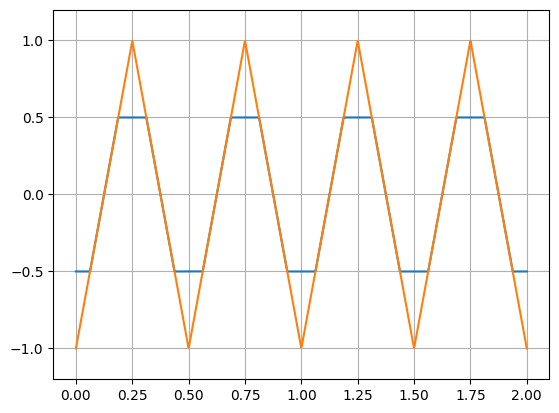

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Define time vector (e.g., 2 seconds, 1000 samples)
t = np.linspace(0, 2, 1000)

#  standard triangle wave
# setting width=0.5 makes it a symmetric triangle wave
triangle = signal.sawtooth(2 * np.pi * 2 * t, width=0.5)

# 3. Clip inakata peaks

trapezoid = np.clip(triangle, -0.5, 0.5)

# Plotting the results
plt.plot(t, trapezoid, label='Trapezoidal Train Wave')
plt.plot(t, triangle, label='Standard Triangle Wave')
plt.grid(True)
plt.ylim(-1.2, 1.2)
plt.show()


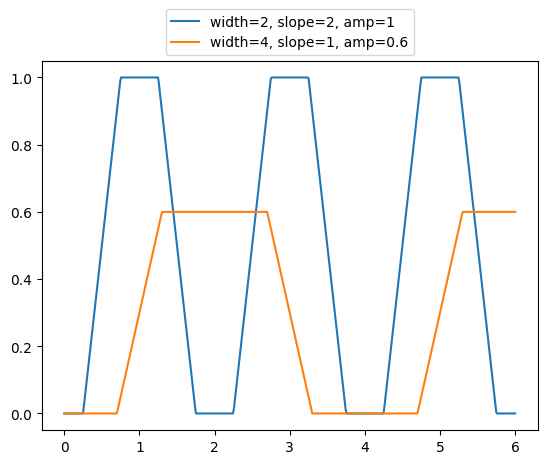

In [ ]:
# you can also hard code it
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np


def trapzoid_signal(t, width=2., slope=1., amp=1., offs=0):
    a = slope*width*signal.sawtooth(2*np.pi*t/width, width=0.5)/4. # inamake sawtooth wave
    a[a>amp/2.] = amp/2. # ka amplitude inapita 1/2 inaicut like the one above
    a[a<-amp/2.] = -amp/2. # same for -ve sode
    return a + amp/2. + offs # offs inacontrol position ya wave either juu or chini depending on thee.

t = np.linspace(0, 6, 501)
plt.plot(t,trapzoid_signal(t, width=2, slope=2, amp=1.), label="width=2, slope=2, amp=1")
plt.plot(t,trapzoid_signal(t, width=4, slope=1, amp=0.6), label="width=4, slope=1, amp=0.6")

plt.legend( loc=(0.25,1.015))
plt.show()


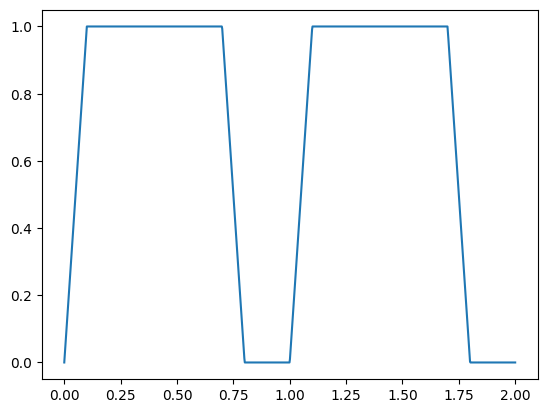

In [ ]:
import numpy as np
# I surprisingly based this from formula za power electronics izo switching characteristics....weird.
# I think I'll use this one cuz naeza eka rise and fall times but you do you gng.
def trapezoidal_pulse_train(t, period, rise, on_time, fall, amplitude=1.0):

    t_wrapped = np.mod(t, period) # inaimake repetitive/periodic over one period for io time yote.

    # Define conditions for each of the 4 phases
    conds = [
        t_wrapped < rise,                                       # Phase 1: Rising
        (t_wrapped >= rise) & (t_wrapped < rise + on_time),     # Phase 2: On/Flat Top
        (t_wrapped >= rise + on_time) & (t_wrapped < rise + on_time + fall), # Phase 3: Falling
        t_wrapped >= (rise + on_time + fall)                    # Phase 4: Off/Flat Bottom
    ]

    # Define math expressions corresponding to each phase
    funcs = [
        lambda x: (amplitude / rise) * x,
        lambda x: amplitude,
        lambda x: amplitude - (amplitude / fall) * (x - rise - on_time),
        lambda x: 0.0
    ]

    return np.piecewise(t_wrapped, conds, funcs)
plt.plot(t, trapezoidal_pulse_train(t, 1, 0.1, 0.6, 0.1, amplitude=1.0))
plt.show()
# for io duty cycle tutamultiply period by duty cycle tumepewa then tutasplit tu tena evenly.. eazy peezy.
# then rise na fall times zitakua 0.05 of period with ton as 0.9

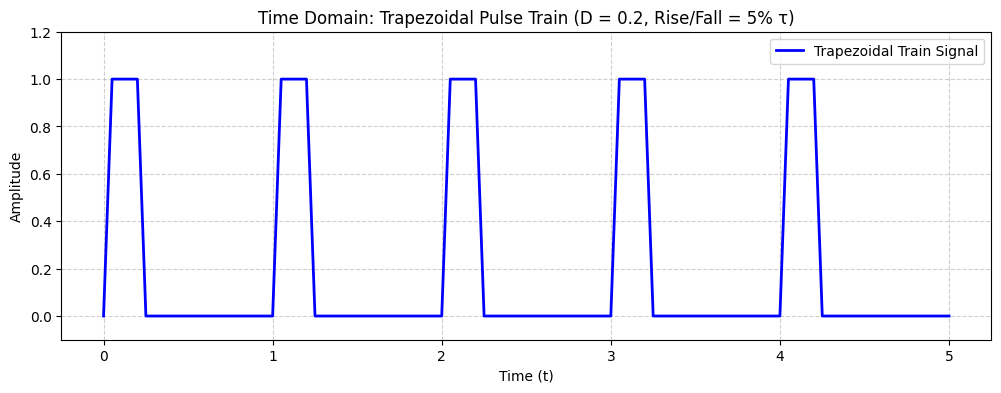

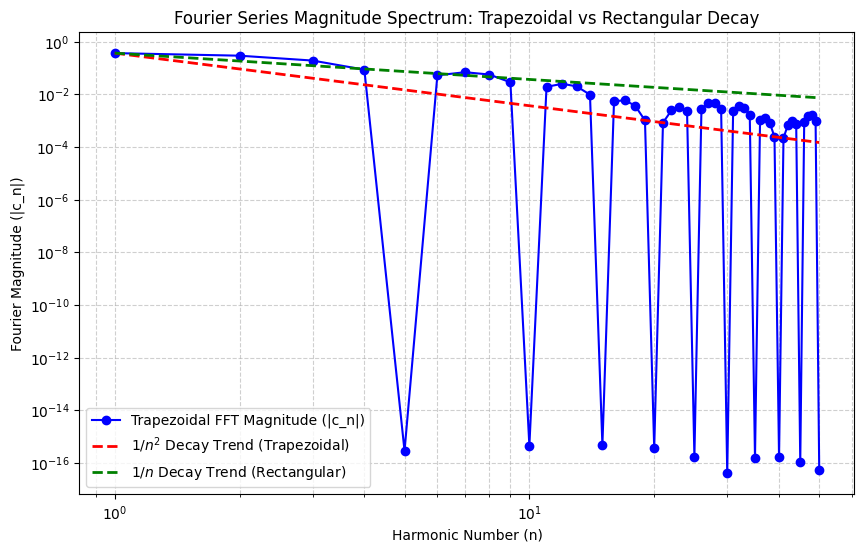

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# TRAPEZOIDAL PULSE TRAIN FUNCTION
# Piecewise defined switching characteristics
def trapezoidal_pulse_train(t, period, rise, on_time, fall, amplitude=1.0):
    t_wrapped = np.mod(t, period) # inaimake repetitive/periodic over one period for io time yote.

    # Define conditions for each of the 4 phases
    conds = [
        t_wrapped < rise,                                         # Phase 1: Rising
        (t_wrapped >= rise) & (t_wrapped < rise + on_time),      # Phase 2: On/Flat Top
        (t_wrapped >= rise + on_time) & (t_wrapped < rise + on_time + fall), # Phase 3: Falling
        t_wrapped >= (rise + on_time + fall)                     # Phase 4: Off/Flat Bottom
    ]

    # Define math expressions corresponding to each phase
    funcs = [
        lambda x: (amplitude / rise) * x,
        lambda x: amplitude,
        lambda x: amplitude - (amplitude / fall) * (x - rise - on_time),
        lambda x: 0.0
    ]
    return np.piecewise(t_wrapped, conds, funcs)

# PARAMETERS SETUP
# D = 0.2, rise/fall times set to 5% of period
period = 1.0                     # T_period = 1.0
duty_cycle = 0.2                 # D = 0.2
rise_time = 0.05 * period        # 5% ya period
fall_time = 0.05 * period        # 5% ya period

# For io duty cycle tutamultiply period by duty cycle then tutasplit evenly
# Active width ni rise/2 + on_time + fall/2 = D * period
on_time = (duty_cycle * period) - (rise_time / 2) - (fall_time / 2)

# Generate time vector with high sample resolution (tumia samples mob ndo spectrum ikuwe clean)
fs = 2000.0                      # Sampling frequency (Hz)
num_periods = 100                # Periods mingi ndo FFT ipate sharp harmonics
t = np.arange(0, num_periods * period, 1/fs)

# Synthesize signal
x = trapezoidal_pulse_train(t, period, rise_time, on_time, fall_time, amplitude=1.0)

# 1. TIME DOMAIN PLOT (Tuna-plot 5 periods kwanza)

plt.figure(figsize=(12, 4))
t_plot_limit = 5 * period
idx_plot = t <= t_plot_limit

plt.plot(t[idx_plot], x[idx_plot], 'b-', linewidth=2, label='Trapezoidal Train Signal')
plt.title('Time Domain: Trapezoidal Pulse Train (D = 0.2, Rise/Fall = 5% τ)')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.ylim(-0.1, 1.2)
plt.grid(True, ls="--", alpha=0.6)
plt.legend()
plt.show()


# 2. FREQUENCY DOMAIN (FFT & DECAY COMPARISON)

# Tuna-calculate Fourier coefficients kutumia FFT
N = len(t)
fft_vals = np.fft.fft(x) / N
freqs = np.fft.fftfreq(N, 1/fs)

# Tunatoa magnitude ya 50 harmonics za kwanza
n_harmonics = np.arange(1, 51)
fft_mag = []

for n in n_harmonics:
    target_freq = n / period
    idx = np.argmin(np.abs(freqs - target_freq))
    # Multiply by 2 for positive/negative frequency components (except DC)
    fft_mag.append(2 * np.abs(fft_vals[idx]))

n_harmonics = np.array(n_harmonics)
fft_mag = np.array(fft_mag)

# Reference slopes za kufanya comparison kwa plot
# 1/n^2 decay ya trapezoid vs 1/n decay ya rectangular square waves
ref_1_over_n2 = fft_mag[0] / (n_harmonics ** 2)
ref_1_over_n = fft_mag[0] / n_harmonics

# PLOTTING FFT SPECTRUM & DECAY COMPARISON
plt.figure(figsize=(10, 6))
plt.loglog(n_harmonics, fft_mag, 'bo-', label='Trapezoidal FFT Magnitude (|c_n|)')
plt.loglog(n_harmonics, ref_1_over_n2, 'r--', linewidth=2, label=r'1/$n^2$ Decay Trend (Trapezoidal)')
plt.loglog(n_harmonics, ref_1_over_n, 'g--', linewidth=2, label=r'1/$n$ Decay Trend (Rectangular)')

plt.title('Fourier Series Magnitude Spectrum: Trapezoidal vs Rectangular Decay')
plt.xlabel('Harmonic Number (n)')
plt.ylabel('Fourier Magnitude (|c_n|)')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.show()